Test check 123

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import importlib
import module
importlib.reload(module)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


METRIC_COLUMNS = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
]


def buy_and_hold_curve(price_series):
    prices = price_series.to_numpy(dtype=float)

    curve = (
        prices
        / prices[0]
    )

    return pd.Series(
        curve,
        index=price_series.index
    )


def evaluate_signal_curve(price_series, signal_frame):
    delayed_signal_frame = module.apply_execution_delay(
        signal_frame,
        delay_days=1
    )

    strategy_values = module.single_signal_portfolio_values(
        price_values=price_series.to_numpy(dtype=float),
        signal_values=delayed_signal_frame["signal"].to_numpy(dtype=float),
        initial_value=1.0
    )

    strategy_curve = pd.Series(
        strategy_values,
        index=price_series.index
    )

    benchmark_curve = buy_and_hold_curve(price_series)

    strategy_stats = module.performance_statistics_from_values(
        strategy_curve.to_numpy(dtype=float)
    )

    benchmark_stats = module.performance_statistics_from_values(
        benchmark_curve.to_numpy(dtype=float)
    )

    return strategy_curve, benchmark_curve, strategy_stats, benchmark_stats


def signal_usage_statistics(signal_frame):
    signal = signal_frame["signal"].to_numpy(dtype=float)

    position_change = np.zeros(len(signal))
    position_change[1:] = np.abs(
        signal[1:]
        - signal[:-1]
    )

    active_share = np.sum(signal) / len(signal)
    number_of_trades = np.sum(position_change)

    return active_share, number_of_trades


def evaluate_candidate(price_series, signal_frame):
    strategy_curve, benchmark_curve, strategy_stats, benchmark_stats = evaluate_signal_curve(
        price_series,
        signal_frame
    )

    active_share, number_of_trades = signal_usage_statistics(
        signal_frame
    )

    strategy_stats["Active Share"] = active_share
    strategy_stats["Number of Trades"] = number_of_trades

    return strategy_stats, strategy_curve, benchmark_curve


def build_statistics_table(
    strategy_name,
    buy_hold_name,
    in_sample_stats,
    buy_hold_in_sample_stats,
    out_sample_stats,
    buy_hold_out_sample_stats,
    full_sample_stats,
    buy_hold_full_sample_stats
):
    df_statistics = pd.DataFrame(
        {
            strategy_name + " In-Sample": in_sample_stats,
            buy_hold_name + " In-Sample": buy_hold_in_sample_stats,
            strategy_name + " Out-of-Sample": out_sample_stats,
            buy_hold_name + " Out-of-Sample": buy_hold_out_sample_stats,
            strategy_name + " Full Sample": full_sample_stats,
            buy_hold_name + " Full Sample": buy_hold_full_sample_stats
        }
    ).T

    df_statistics = df_statistics[METRIC_COLUMNS]

    return df_statistics.round(4)


def plot_strategy_vs_buy_hold(
    strategy_curve,
    buy_hold_curve,
    title,
    strategy_label,
    buy_hold_label,
    out_of_sample_start
):
    plt.figure(figsize=(12, 5))

    plt.plot(
        strategy_curve.index,
        strategy_curve.to_numpy(dtype=float),
        label=strategy_label
    )

    plt.plot(
        buy_hold_curve.index,
        buy_hold_curve.to_numpy(dtype=float),
        label=buy_hold_label,
        linestyle="--"
    )

    plt.axvline(
        pd.Timestamp(out_of_sample_start),
        linestyle=":",
        label="Out-of-sample start"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Wealth index")
    plt.legend()
    plt.grid(True)
    plt.show()

# Research Notebook: In-Sample Calibration and Out-of-Sample Backtest of Three Trading Signals

This notebook evaluates three simple trading signals using daily close prices only.  
Each signal trades one ETF and is compared against buy-and-hold of the same ETF.

The three traded assets are:

1. SPY, using a VIX term-structure signal.
2. XLE, using crude oil momentum, XLE momentum, and XLE relative strength versus SPY.
3. ITA, using a defensive volatility and relative-strength signal.

The sample is split into an in-sample calibration period and an out-of-sample evaluation period.  
The parameters are estimated only on the in-sample period.  
The selected parameter set is then evaluated in-sample, out-of-sample, and over the full sample.

The trading rule uses the same timing assumption as the backtest files:

$$
\text{Signal at close } t
\quad \Rightarrow \quad
\text{trade at close } t+1
$$

Therefore, a signal observed at close \(t\) earns the return from \(t+1\) to \(t+2\).  
This avoids look-ahead bias because the strategy never trades on information before it is available.

The basic momentum variable is:

$$
M_t^{(n)} = \frac{P_t}{P_{t-n}} - 1
$$

The moving average is:

$$
MA_t^{(n)} = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}
$$

For every strategy and buy-and-hold benchmark, the following statistics are computed:

$$
R_{\text{ann}} =
\left(\frac{W_T}{W_0}\right)^{252/N} - 1
$$

$$
\sigma_{\text{ann}} =
\sqrt{252}\cdot \sigma(r_t)
$$

$$
\text{Sharpe} =
\frac{252\cdot \bar r}{\sigma_{\text{ann}}}
$$

$$
\text{Max Drawdown} =
\min_t \left(\frac{W_t}{\max_{s \leq t} W_s} - 1\right)
$$

In [2]:
PERIODS_PER_YEAR = 252

METRIC_COLUMNS = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
]


def buy_and_hold_curve(price_series):
    prices = price_series.to_numpy(dtype=float)
    wealth = prices / prices[0]
    return pd.Series(wealth, index=price_series.index)


def evaluate_signal_curve(price_series, raw_signal_frame):
    delayed_signal_frame = module.apply_execution_delay(
        raw_signal_frame,
        delay_days=1
    )

    strategy_values = module.single_signal_portfolio_values(
        price_values=price_series.to_numpy(dtype=float),
        signal_values=delayed_signal_frame["signal"].to_numpy(dtype=float),
        initial_value=1.0
    )

    strategy_curve = pd.Series(
        strategy_values,
        index=price_series.index
    )

    buy_hold = buy_and_hold_curve(price_series)

    strategy_stats = module.performance_statistics_from_values(
        strategy_curve.to_numpy(dtype=float),
        periods_per_year=PERIODS_PER_YEAR
    )

    buy_hold_stats = module.performance_statistics_from_values(
        buy_hold.to_numpy(dtype=float),
        periods_per_year=PERIODS_PER_YEAR
    )

    return strategy_curve, buy_hold, strategy_stats, buy_hold_stats


def build_statistics_table(
    strategy_name,
    buy_hold_name,
    in_sample_stats,
    buy_hold_in_sample_stats,
    out_sample_stats,
    buy_hold_out_sample_stats,
    full_sample_stats,
    buy_hold_full_sample_stats
):
    df_statistics = pd.DataFrame(
        {
            strategy_name + " In-Sample": in_sample_stats,
            buy_hold_name + " In-Sample": buy_hold_in_sample_stats,
            strategy_name + " Out-of-Sample": out_sample_stats,
            buy_hold_name + " Out-of-Sample": buy_hold_out_sample_stats,
            strategy_name + " Full Sample": full_sample_stats,
            buy_hold_name + " Full Sample": buy_hold_full_sample_stats
        }
    ).T

    df_statistics = df_statistics[METRIC_COLUMNS]

    return df_statistics.round(4)


def plot_strategy_vs_buy_hold(
    strategy_curve,
    buy_hold_curve,
    title,
    strategy_label,
    buy_hold_label,
    out_of_sample_start
):
    plt.figure(figsize=(12, 5))

    plt.plot(
        strategy_curve.index,
        strategy_curve.to_numpy(dtype=float),
        label=strategy_label
    )

    plt.plot(
        buy_hold_curve.index,
        buy_hold_curve.to_numpy(dtype=float),
        label=buy_hold_label,
        linestyle="--"
    )

    plt.axvline(
        pd.Timestamp(out_of_sample_start),
        linestyle=":",
        label="Out-of-sample start"
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Wealth index")
    plt.legend()
    plt.grid(True)
    plt.show()

# Signal 0: SPY / VIX Term-Structure Strategy

This signal trades **SPY**. The VIX and VIX3M are not traded directly. They are only used as information variables to decide whether the market environment is favourable for holding SPY.

## Economic motivation and literature

The main idea of this signal is that the shape of the volatility curve gives information about the current risk environment in the equity market.

The VIX measures short-term expected volatility, while VIX3M measures expected volatility over a longer horizon of around three months. I use the following ratio as a simple proxy for the slope of the volatility curve:

$$
R_t^{VIX}
=

\frac{VIX3M_t}{VIX_t}
$$

The volatility curve is upward sloping when:

$$
VIX3M_t > VIX_t
$$

or equivalently:

$$
R_t^{VIX}>1
$$

This is usually interpreted as a more normal volatility environment. Short-term expected volatility is lower than three-month expected volatility, so the market is not pricing unusually high immediate stress because an upward-sloping VIX term structure is its historically usual configuration (Fassas & Hourvouliades, 2019, p. 6).

The volatility curve is inverted when:

$$
VIX_t > VIX3M_t
$$

or equivalently:

$$
R_t^{VIX}<1
$$

This is usually interpreted as a stress environment because short-term volatility is high relative to longer-term volatility (Fassas & Hourvouliades, 2019, p. 7). This may reflect demand for equity-portfolio protection through put options (Fassas, 2012, p. 3).

Fassas (2012) documents a statistically significant relationship between the VIX futures term structure and S&P 500 returns and finds evidence that the term structure can act as a contrarian equity-timing indicator. Fassas and Hourvouliades (2019) also find that the shape of the VIX futures curve contains information about future equity-price movements.

The ratio used in this notebook is a simplified version of this idea. Instead of using the full VIX futures curve, I compare VIX3M with VIX. The in-sample parameter calibration selects a threshold of 1.10. Therefore, the strategy only buys SPY when the curve is clearly upward sloping:

$$
R_t^{VIX}>1.10
$$

The second part of the signal is a momentum filter. Moskowitz, Ooi, and Pedersen (2012) show that time-series momentum exists across different asset classes, including equity indices, bonds, commodities, and currencies. Based on this idea, I also require SPY's own medium-term momentum to not be too weak.

This is important because the volatility curve should not be used alone. The curve may look normal again after a market decline, but SPY itself could still be in a weak trend. The momentum filter helps avoid buying SPY during such periods.

The literature therefore supports the two main components of the signal:

1. the VIX term structure as a volatility-regime indicator;
2. SPY momentum as a trend-confirmation filter.

The exact lookback window and thresholds are not taken directly from the papers. They are selected empirically from the in-sample parameter grid calibration in this notebook.

## Signal conditions

The volatility term-structure proxy is:

$$
R_t^{VIX}
=

\frac{VIX3M_t}{VIX_t}
$$

SPY time-series momentum over an $n$-day lookback is:

$$
M_t^{SPY}(n)
=

\frac{SPY_t}{SPY_{t-n}}-1
$$

The in-sample calibration selects:

$$
n=168
$$

$$
R_t^{VIX}>1.10
$$

$$
M_t^{SPY}(168)>-0.025
$$

Therefore, the final signal is:

$$
S_t^{SPY}
=

\begin{cases}
1, & \text{if } R_t^{VIX}>1.10 \text{ and } M_t^{SPY}(168)>-0.025 \
0, & \text{otherwise}
\end{cases}
$$

This means the strategy buys SPY only when the volatility curve is clearly upward sloping and SPY has not shown strong medium-term weakness.

The slightly negative momentum threshold is used as a tolerance filter. SPY does not need to have a strongly positive return over the lookback period, but it should also not be in a pronounced decline.

The common execution rule remains:

$$
\text{Signal observed at close }t
\quad\Rightarrow\quad
\text{trade at close }t+1
$$

This timing rule avoids look-ahead bias, because the strategy does not trade before the signal information is available.

## Bibliography

* Fassas, A. P. (2012). *The relationship between VIX futures term structure and S&P 500 returns*. SSRN Electronic Journal, Abstract 2841384.
* Fassas, A. P., & Hourvouliades, N. (2019). VIX futures as a market timing indicator. *Journal of Risk and Financial Management, 12*(3), 113. https://doi.org/10.3390/jrfm12030113
* Moskowitz, T. J., Ooi, Y. H., & Pedersen, L. H. (2012). Time series momentum. *Journal of Financial Economics, 104*(2), 228-250. https://doi.org/10.1016/j.jfineco.2011.11.003


Signal 0 top 10 parameter combinations:


,Ratio Threshold,Momentum Window,Momentum Threshold,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Rank
0,1.10,168,-0.025,0.0561,0.0722,0.7928,-0.0764,0.3839,188.0,1
1,1.10,168,-0.050,0.0553,0.0732,0.7721,-0.0947,0.3928,186.0,2
2,1.10,252,-0.025,0.0532,0.0717,0.7582,-0.1006,0.3796,158.0,3
3,1.10,63,0.025,0.0469,0.0635,0.7541,-0.0760,0.3510,180.0,4
4,1.00,126,0.025,0.0716,0.0983,0.7531,-0.1722,0.5903,101.0,5
5,0.90,126,0.025,0.0761,0.1058,0.7468,-0.2091,0.6307,53.0,6
6,0.85,126,0.025,0.0755,0.1061,0.7396,-0.2114,0.6330,47.0,7
7,1.10,252,-0.050,0.0520,0.0721,0.7392,-0.1006,0.3820,160.0,8
8,0.90,168,0.000,0.0809,0.1150,0.7343,-0.1735,0.6640,51.0,9
9,1.10,252,0.000,0.0503,0.0709,0.7285,-0.0955,0.3778,160.0,10


Selected Signal 0 parameters:
Ratio threshold: 1.1
Momentum window: 168
Momentum threshold: -0.025


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
SPY VIX Strategy In-Sample,0.0561,0.0722,0.7928,-0.0764
Buy and Hold SPY In-Sample,0.0847,0.2164,0.4837,-0.5519
SPY VIX Strategy Out-of-Sample,0.0720,0.0818,0.8918,-0.1770
Buy and Hold SPY Out-of-Sample,0.1354,0.1779,0.8033,-0.3372
SPY VIX Strategy Full Sample,0.0613,0.0797,0.7863,-0.1770
Buy and Hold SPY Full Sample,0.1130,0.1956,0.6453,-0.5519


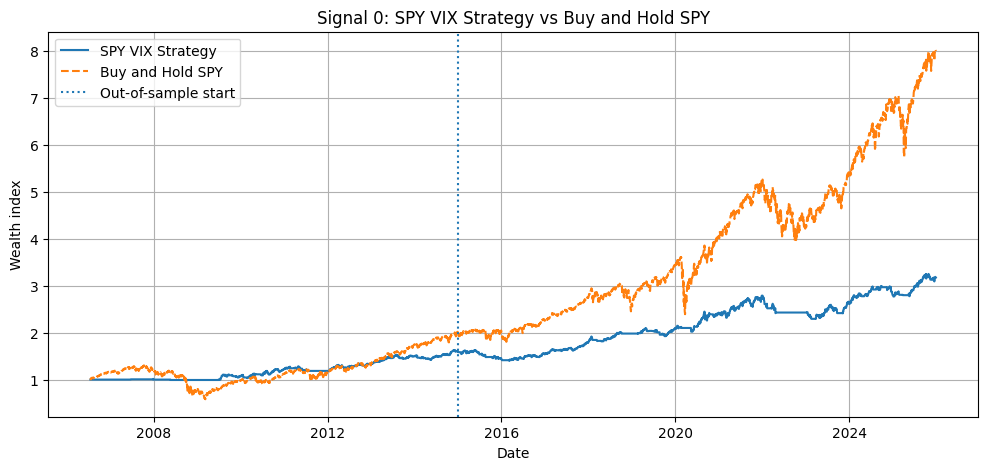

In [3]:
# ============================================================
# Signal 0: SPY / VIX term-structure strategy
# Parameter estimation and evaluation
# ============================================================

signal_0_tickers = [
    "SPY",
    "^VIX",
    "^VIX3M"
]

signal_0_start_date = "2004-01-01"
signal_0_end_date = "2025-12-31"

signal_0_in_sample_start = "2006-07-17"
signal_0_in_sample_end = "2014-12-31"

signal_0_out_sample_start = "2015-01-01"
signal_0_out_sample_end = "2025-12-31"

df_signal_0_prices, _ = module.download_stock_price_data(
    signal_0_tickers,
    signal_0_start_date,
    signal_0_end_date
)

spy_series = df_signal_0_prices["SPY"]
vix_series = df_signal_0_prices["^VIX"]
vix3m_series = df_signal_0_prices["^VIX3M"]

spy_in_sample = spy_series.loc[
    signal_0_in_sample_start:signal_0_in_sample_end
]

spy_out_sample = spy_series.loc[
    signal_0_out_sample_start:signal_0_out_sample_end
]

spy_full_sample = spy_series.loc[
    signal_0_in_sample_start:signal_0_out_sample_end
]

ratio_thresholds = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
momentum_windows = [63, 126, 168, 210, 252]
momentum_thresholds = [-0.05, -0.025, 0.00, 0.025, 0.05]

calibration_results = []

for ratio_threshold in ratio_thresholds:
    for momentum_window in momentum_windows:
        for momentum_threshold in momentum_thresholds:

            signal_frame = module.vix_term_structure_signal(
                target_series=spy_in_sample,
                vix_series=vix_series,
                vix3m_series=vix3m_series,
                ratio_threshold=ratio_threshold,
                momentum_window=momentum_window,
                momentum_threshold=momentum_threshold
            )

            stats, _, _ = evaluate_candidate(
                spy_in_sample,
                signal_frame
            )

            stats["Ratio Threshold"] = ratio_threshold
            stats["Momentum Window"] = momentum_window
            stats["Momentum Threshold"] = momentum_threshold

            calibration_results.append(stats)

df_signal_0_results = pd.DataFrame(calibration_results)

df_signal_0_results = df_signal_0_results[
    [
        "Ratio Threshold",
        "Momentum Window",
        "Momentum Threshold",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown",
        "Active Share",
        "Number of Trades"
    ]
]

df_signal_0_results = df_signal_0_results.sort_values(
    by="Sharpe Ratio",
    ascending=False
).reset_index(drop=True)

df_signal_0_results["Rank"] = np.arange(1, len(df_signal_0_results) + 1)

print("Signal 0 top 10 parameter combinations:")
display(df_signal_0_results.head(10).round(4))

best_signal_0 = df_signal_0_results.iloc[0]

signal_0_ratio_threshold = float(best_signal_0["Ratio Threshold"])
signal_0_momentum_window = int(best_signal_0["Momentum Window"])
signal_0_momentum_threshold = float(best_signal_0["Momentum Threshold"])

print("Selected Signal 0 parameters:")
print("Ratio threshold:", signal_0_ratio_threshold)
print("Momentum window:", signal_0_momentum_window)
print("Momentum threshold:", signal_0_momentum_threshold)


def make_signal_0(price_series):
    return module.vix_term_structure_signal(
        target_series=price_series,
        vix_series=vix_series,
        vix3m_series=vix3m_series,
        ratio_threshold=signal_0_ratio_threshold,
        momentum_window=signal_0_momentum_window,
        momentum_threshold=signal_0_momentum_threshold
    )


signal_0_in = make_signal_0(spy_in_sample)
signal_0_out = make_signal_0(spy_out_sample)
signal_0_full = make_signal_0(spy_full_sample)

strategy_0_in, buy_hold_0_in, stats_0_in, bh_0_in = evaluate_signal_curve(
    spy_in_sample,
    signal_0_in
)

strategy_0_out, buy_hold_0_out, stats_0_out, bh_0_out = evaluate_signal_curve(
    spy_out_sample,
    signal_0_out
)

strategy_0_full, buy_hold_0_full, stats_0_full, bh_0_full = evaluate_signal_curve(
    spy_full_sample,
    signal_0_full
)

df_signal_0_statistics = build_statistics_table(
    strategy_name="SPY VIX Strategy",
    buy_hold_name="Buy and Hold SPY",
    in_sample_stats=stats_0_in,
    buy_hold_in_sample_stats=bh_0_in,
    out_sample_stats=stats_0_out,
    buy_hold_out_sample_stats=bh_0_out,
    full_sample_stats=stats_0_full,
    buy_hold_full_sample_stats=bh_0_full
)

display(df_signal_0_statistics)

plot_strategy_vs_buy_hold(
    strategy_curve=strategy_0_full,
    buy_hold_curve=buy_hold_0_full,
    title="Signal 0: SPY VIX Strategy vs Buy and Hold SPY",
    strategy_label="SPY VIX Strategy",
    buy_hold_label="Buy and Hold SPY",
    out_of_sample_start=signal_0_out_sample_start
)

# Signal 1: Oil / Energy Relative-Strength Strategy

This signal trades **XLE** (Energy Select Sector SPDR Fund). XLE is an energy-sector equity ETF, so it represents energy companies rather than crude oil itself. Crude-oil futures and SPY are only used as information variables in this rule; they are never traded by the strategy.

## Economic motivation and literature

The economic idea behind this signal is that energy stocks should perform better when both the energy sector itself and the oil market are in a supportive condition. Since many companies in the energy sector are connected to oil and gas production, refining, transportation, or energy services, crude oil prices can contain useful information about the business environment of these firms.

Sadorsky (2001, p. 17) finds that crude oil prices have a large and significant impact on Canadian oil and gas stock returns. He also reports that an increase in the oil price factor increases returns to Canadian oil and gas stocks. This supports the idea that crude oil can be used as an information variable for energy-sector equities.

The economic mechanism is also intuitive. Sadorsky (2001, p. 20) explains that lower oil prices can reduce profit margins and capital expenditures, while higher oil prices can improve profit margins and possibly increase capital expenditures. For this reason, crude oil prices are likely to be a relevant risk factor for oil and gas stock returns.

Elyasiani, Mansur and Odusami (2011, p. 966) provide further support at the US industry level. They find that oil price fluctuations can be interpreted as a systematic asset-pricing risk at the industry level. In their study, nine out of thirteen US industries show a statistically significant relationship with oil-futures returns, oil-futures volatility, or both. This supports the general idea that oil-price information can matter for sector returns.

At the same time, oil prices alone are not enough to justify buying XLE. XLE is still an equity ETF, not a commodity future. Its return also depends on the broad stock market, investor sentiment, company earnings, costs, balance sheets, and sector rotation. Therefore, this strategy does not simply buy XLE whenever oil prices increase. Instead, oil momentum is only one filter within a broader signal.

The trend-following part of the strategy is motivated by the momentum literature. Moskowitz, Ooi and Pedersen (2012, p. 228) document significant time-series momentum in equity-index, currency, commodity and bond futures. They find return persistence over horizons of approximately one to twelve months. This supports the use of past returns as a signal for future returns.

Hurst, Ooi and Pedersen (2017, p. 1) extend this idea over a much longer historical period. They study trend-following investing across global markets since 1880 and find positive average returns in each decade of their sample. They also describe time-series momentum as going long markets with recent positive returns and shorting markets with recent negative returns (Hurst, Ooi and Pedersen, 2017, p. 2). This supports the general use of trend and momentum filters in this signal.

The strategy therefore combines two ideas. First, crude oil is used as a state variable for the energy sector. Second, XLE itself must show positive trend and momentum confirmation. In addition, the XLE/SPY ratio is used to check whether energy stocks are holding up relative to the broad US equity market.

The relative-strength part is important because XLE can rise simply because the whole equity market is rising. By comparing XLE with SPY, the signal checks whether energy equities are doing reasonably well compared with the overall market. This helps distinguish energy-sector strength from a general stock-market rally.

Overall, the signal tries to buy XLE only when several conditions point in the same direction: XLE is in a positive trend, crude oil is not in a severe decline, XLE has positive own momentum, and energy stocks are not strongly underperforming the broad market.

The literature supports the individual building blocks of the strategy, especially oil-price relevance for energy stocks and trend-following across asset classes. However, the cited papers do not test this exact XLE-oil-SPY composite signal. Therefore, the strategy is treated as a research hypothesis, and the exact parameter values are selected only from the in-sample grid calibration.

## Signal conditions

For any price series $P$, momentum over $n$ trading days is:

$$
M_t^{P}(n)
=

\frac{P_t}{P_{t-n}}-1
$$

The calibrated XLE trend and absolute-momentum conditions are:

$$
XLE_t>MA_t^{XLE}(200)
$$

$$
M_t^{XLE}(210)>0
$$

Crude-oil momentum must satisfy:

$$
M_t^{Oil}(126)>-0.05
$$

The relative-strength ratio is:

$$
RS_t^{XLE/SPY}
=

\frac{XLE_t}{SPY_t}
$$

and the relative-strength momentum is:

$$
M_t^{RS}(21)
=

\frac{RS_t^{XLE/SPY}}{RS_{t-21}^{XLE/SPY}}-1
$$

with the calibrated requirement:

$$
M_t^{RS}(21)>-0.025
$$

The final rule is therefore:

$$
S_t^{XLE}
=

\begin{cases}
1, & \text{if all four conditions are satisfied at close }t \
0, & \text{otherwise}
\end{cases}
$$

The mildly negative oil and relative-strength thresholds allow small setbacks. Oil does not need to be strongly rising, and XLE does not need to strongly outperform SPY at every point in time. However, both variables should not be meaningfully weak. At the same time, the 200-day trend filter and the positive 210-day XLE momentum condition keep the strategy focused on longer-term trend confirmation.

These parameter values are empirical selections from the in-sample calibration. They are not direct recommendations from the cited studies.

The common execution rule remains:

$$
\text{Signal observed at close }t
\quad\Rightarrow\quad
\text{trade at close }t+1
$$

This timing rule avoids look-ahead bias, because the strategy does not trade before the signal information is available.

## Bibliography

* Sadorsky, P. (2001). Risk factors in stock returns of Canadian oil and gas companies. *Energy Economics, 23*(1), 17-28. https://doi.org/10.1016/S0140-9883(00)00072-4
* Elyasiani, E., Mansur, I., & Odusami, B. (2011). Oil price shocks and industry stock returns. *Energy Economics, 33*(5), 966-974. https://doi.org/10.1016/j.eneco.2011.03.013
* Hurst, B., Ooi, Y. H., & Pedersen, L. H. (2017). A century of evidence on trend-following investing. *The Journal of Portfolio Management, 44*(1), 15-29. https://doi.org/10.3905/jpm.2017.44.1.015
* Moskowitz, T. J., Ooi, Y. H., & Pedersen, L. H. (2012). Time series momentum. *Journal of Financial Economics, 104*(2), 228-250. https://doi.org/10.1016/j.jfineco.2011.11.003


Signal 1 top 10 parameter combinations:


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Trend Window,Oil Momentum Window,Oil Momentum Threshold,Target Momentum Window,Target Momentum Threshold,Relative Strength Window,Relative Strength Threshold,Calibration Score,Rank
0,0.0905,0.1444,0.6727,-0.2206,0.4411,182.0,200,126,-0.05,210,0.000,21,-0.025,0.7633,1
1,0.0881,0.1421,0.6657,-0.2444,0.4133,146.0,150,126,-0.05,210,0.025,63,-0.025,0.7538,2
2,0.0855,0.1417,0.6501,-0.2206,0.4358,192.0,150,126,-0.05,210,0.000,21,-0.025,0.7355,3
3,0.0853,0.1425,0.6456,-0.2444,0.4191,156.0,150,126,-0.05,210,0.000,63,-0.025,0.7308,4
4,0.0843,0.1410,0.6449,-0.2468,0.4283,176.0,150,126,-0.05,210,0.025,21,-0.025,0.7292,5
5,0.0855,0.1440,0.6418,-0.2345,0.4344,166.0,200,126,-0.05,210,0.025,21,-0.025,0.7273,6
6,0.0837,0.1412,0.6400,-0.2444,0.4086,148.0,150,126,-0.05,210,0.050,63,-0.025,0.7236,7
7,0.0807,0.1398,0.6253,-0.2224,0.4230,180.0,150,126,-0.05,210,0.050,21,-0.025,0.7060,8
8,0.0805,0.1401,0.6228,-0.2363,0.4019,140.0,150,126,-0.05,210,0.075,63,-0.025,0.7033,9
9,0.0795,0.1392,0.6197,-0.2461,0.3644,92.0,150,126,-0.05,210,0.025,126,0.000,0.6992,10


Signal 1 selection method:
Best calibration score after robustness filters
Selected Signal 1 parameters:
Trend window: 200
Oil momentum window: 126
Oil momentum threshold: -0.05
Target momentum window: 210
Target momentum threshold: 0.0
Relative strength window: 21
Relative strength threshold: -0.025


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Oil Energy Strategy In-Sample,0.0905,0.1444,0.6727,-0.2206
Buy and Hold XLE In-Sample,0.0807,0.2852,0.4153,-0.5736
Oil Energy Strategy Out-of-Sample,0.0453,0.1356,0.3950,-0.4228
Buy and Hold XLE Out-of-Sample,0.0523,0.2937,0.3216,-0.6681
Oil Energy Strategy Full Sample,0.0706,0.1406,0.5560,-0.4228
Buy and Hold XLE Full Sample,0.0685,0.2889,0.3745,-0.7126


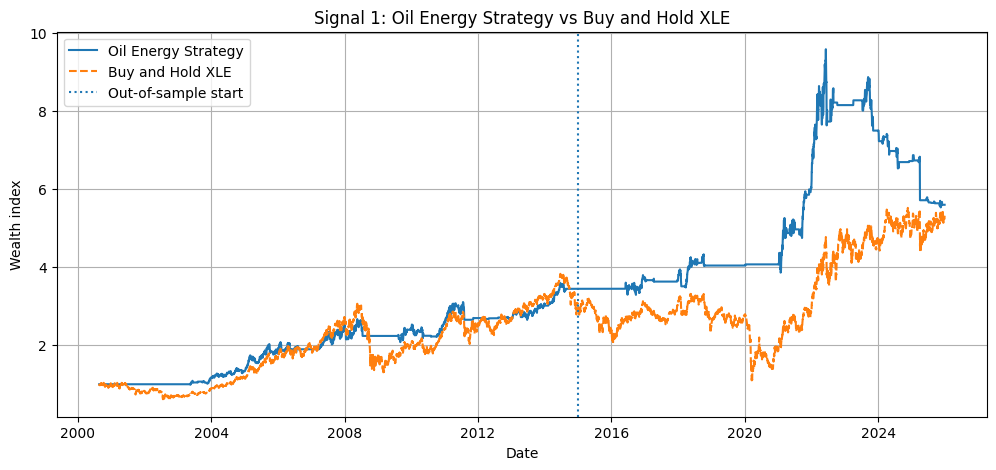

In [4]:
# ============================================================
# Signal 1: Oil / Energy relative-strength strategy
# ============================================================

signal_1_tickers = ["XLE", "CL=F", "SPY"]

signal_1_start_date = "2000-01-01"
signal_1_end_date = "2025-12-31"

signal_1_in_sample_start = "2000-01-01"
signal_1_in_sample_end = "2014-12-31"

signal_1_out_sample_start = "2015-01-01"
signal_1_out_sample_end = "2025-12-31"

df_signal_1_prices, _ = module.download_stock_price_data(
    signal_1_tickers,
    signal_1_start_date,
    signal_1_end_date
)

xle_series = df_signal_1_prices["XLE"]
oil_series = df_signal_1_prices["CL=F"]
market_series = df_signal_1_prices["SPY"]

xle_in_sample = xle_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

oil_in_sample = oil_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

market_in_sample = market_series.loc[
    signal_1_in_sample_start:signal_1_in_sample_end
]

xle_out_sample = xle_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

oil_out_sample = oil_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

market_out_sample = market_series.loc[
    signal_1_out_sample_start:signal_1_out_sample_end
]

xle_full_sample = xle_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]

oil_full_sample = oil_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]

market_full_sample = market_series.loc[
    signal_1_in_sample_start:signal_1_out_sample_end
]


# ============================================================
# Parameter grid
# ============================================================

trend_windows = [100, 150, 200, 250]

oil_momentum_windows = [21, 63, 126]
oil_momentum_thresholds = [-0.05, 0.00, 0.05, 0.10]

target_momentum_windows = [63, 126, 168, 210]
target_momentum_thresholds = [0.00, 0.025, 0.05, 0.075]

relative_strength_windows = [21, 63, 126]
relative_strength_thresholds = [-0.025, 0.00, 0.025, 0.05]


# ============================================================
# In-sample calibration
# ============================================================

calibration_results = []

for trend_window in trend_windows:
    for oil_momentum_window in oil_momentum_windows:
        for oil_momentum_threshold in oil_momentum_thresholds:
            for target_momentum_window in target_momentum_windows:
                for target_momentum_threshold in target_momentum_thresholds:
                    for relative_strength_window in relative_strength_windows:
                        for relative_strength_threshold in relative_strength_thresholds:

                            signal_frame = module.oil_energy_relative_strength_signal(
                                target_series=xle_in_sample,
                                oil_series=oil_in_sample,
                                market_series=market_in_sample,
                                trend_window=trend_window,
                                oil_momentum_window=oil_momentum_window,
                                oil_momentum_threshold=oil_momentum_threshold,
                                target_momentum_window=target_momentum_window,
                                target_momentum_threshold=target_momentum_threshold,
                                relative_strength_window=relative_strength_window,
                                relative_strength_threshold=relative_strength_threshold
                            )

                            stats, _, _ = evaluate_candidate(
                                xle_in_sample,
                                signal_frame
                            )

                            stats["Trend Window"] = trend_window
                            stats["Oil Momentum Window"] = oil_momentum_window
                            stats["Oil Momentum Threshold"] = oil_momentum_threshold
                            stats["Target Momentum Window"] = target_momentum_window
                            stats["Target Momentum Threshold"] = target_momentum_threshold
                            stats["Relative Strength Window"] = relative_strength_window
                            stats["Relative Strength Threshold"] = relative_strength_threshold

                            calibration_results.append(stats)


df_signal_1_results = pd.DataFrame(calibration_results)

df_signal_1_results["Calibration Score"] = (
    df_signal_1_results["Sharpe Ratio"]
    + df_signal_1_results["Annualized Return"]
)

df_signal_1_results = df_signal_1_results.sort_values(
    by="Calibration Score",
    ascending=False
).reset_index(drop=True)

df_signal_1_results["Rank"] = np.arange(
    1,
    len(df_signal_1_results) + 1
)

print("Signal 1 top 10 parameter combinations:")
display(df_signal_1_results.head(10).round(4))


# ============================================================
# Robustness filters
# ============================================================

df_signal_1_reasonable = df_signal_1_results[
    (df_signal_1_results["Active Share"] >= 0.20)
    & (df_signal_1_results["Active Share"] <= 0.95)
    & (df_signal_1_results["Max Drawdown"] >= -0.50)
    & (df_signal_1_results["Number of Trades"] <= 700)
].copy()

if len(df_signal_1_reasonable) > 0:
    best_signal_1 = df_signal_1_reasonable.iloc[0]
    selection_method_1 = "Best calibration score after robustness filters"
else:
    best_signal_1 = df_signal_1_results.iloc[0]
    selection_method_1 = "Best calibration score without filters"

print("Signal 1 selection method:")
print(selection_method_1)


# ============================================================
# Selected parameters
# ============================================================

signal_1_trend_window = int(best_signal_1["Trend Window"])

signal_1_oil_momentum_window = int(best_signal_1["Oil Momentum Window"])
signal_1_oil_momentum_threshold = float(best_signal_1["Oil Momentum Threshold"])

signal_1_target_momentum_window = int(best_signal_1["Target Momentum Window"])
signal_1_target_momentum_threshold = float(best_signal_1["Target Momentum Threshold"])

signal_1_relative_strength_window = int(best_signal_1["Relative Strength Window"])
signal_1_relative_strength_threshold = float(best_signal_1["Relative Strength Threshold"])

print("Selected Signal 1 parameters:")
print("Trend window:", signal_1_trend_window)
print("Oil momentum window:", signal_1_oil_momentum_window)
print("Oil momentum threshold:", signal_1_oil_momentum_threshold)
print("Target momentum window:", signal_1_target_momentum_window)
print("Target momentum threshold:", signal_1_target_momentum_threshold)
print("Relative strength window:", signal_1_relative_strength_window)
print("Relative strength threshold:", signal_1_relative_strength_threshold)


# ============================================================
# Evaluation with selected parameters
# ============================================================

def make_signal_1(price_series, oil_info_series, market_info_series):

    return module.oil_energy_relative_strength_signal(
        target_series=price_series,
        oil_series=oil_info_series,
        market_series=market_info_series,
        trend_window=signal_1_trend_window,
        oil_momentum_window=signal_1_oil_momentum_window,
        oil_momentum_threshold=signal_1_oil_momentum_threshold,
        target_momentum_window=signal_1_target_momentum_window,
        target_momentum_threshold=signal_1_target_momentum_threshold,
        relative_strength_window=signal_1_relative_strength_window,
        relative_strength_threshold=signal_1_relative_strength_threshold
    )


signal_1_in = make_signal_1(
    xle_in_sample,
    oil_in_sample,
    market_in_sample
)

signal_1_out = make_signal_1(
    xle_out_sample,
    oil_out_sample,
    market_out_sample
)

signal_1_full = make_signal_1(
    xle_full_sample,
    oil_full_sample,
    market_full_sample
)


strategy_1_in, buy_hold_1_in, stats_1_in, bh_1_in = evaluate_signal_curve(
    xle_in_sample,
    signal_1_in
)

strategy_1_out, buy_hold_1_out, stats_1_out, bh_1_out = evaluate_signal_curve(
    xle_out_sample,
    signal_1_out
)

strategy_1_full, buy_hold_1_full, stats_1_full, bh_1_full = evaluate_signal_curve(
    xle_full_sample,
    signal_1_full
)


df_signal_1_statistics = build_statistics_table(
    strategy_name="Oil Energy Strategy",
    buy_hold_name="Buy and Hold XLE",
    in_sample_stats=stats_1_in,
    buy_hold_in_sample_stats=bh_1_in,
    out_sample_stats=stats_1_out,
    buy_hold_out_sample_stats=bh_1_out,
    full_sample_stats=stats_1_full,
    buy_hold_full_sample_stats=bh_1_full
)

display(df_signal_1_statistics)


plot_strategy_vs_buy_hold(
    strategy_curve=strategy_1_full,
    buy_hold_curve=buy_hold_1_full,
    title="Signal 1: Oil Energy Strategy vs Buy and Hold XLE",
    strategy_label="Oil Energy Strategy",
    buy_hold_label="Buy and Hold XLE",
    out_of_sample_start=signal_1_out_sample_start
)

# Summary

The table below collects the main in-sample, out-of-sample and full-sample results for the three strategies.

The purpose of the research notebook is not to recalibrate parameters.  
Instead, it documents whether the selected parameters remain useful when evaluated out of sample and compared with simple buy-and-hold exposure to the same underlying ETF.

In [5]:
df_all_statistics = pd.concat(
    [
        df_signal_0_statistics,
        df_signal_1_statistics,
        df_signal_3_statistics
    ],
    axis=0
)

df_all_statistics.round(4)

NameError: name 'df_signal_3_statistics' is not defined

# Signal 3: Gold Safe-Haven Strategy

This signal trades **GLD** (SPDR Gold Shares ETF).  
TLT (iShares 20+ Year Treasury Bond ETF) is used only as an information variable — it is never traded directly.

## Economic motivation and literature

The signal combines two well-established ideas from the academic literature:

**Trend-following across asset classes (Faber 2007):**  
Faber, M. T. (2007). *A quantitative approach to tactical asset allocation*. Journal of Wealth Management, 9(4), 69–79.  
Faber shows that holding an asset only when it is above its 10-month moving average dramatically reduces drawdowns across equities, bonds, commodities and gold without giving up much return.

**Dual momentum / absolute momentum (Antonacci 2014):**  
Antonacci, G. (2014). *Dual Momentum Investing*. McGraw-Hill.  
Antonacci documents that assets with positive 12-month absolute momentum (i.e. the asset is higher today than it was 12 months ago) tend to keep outperforming over the next month. Combining absolute momentum with a trend filter strengthens both the entry signal and the drawdown protection.

**Gold as a safe haven (Baur & Lucey 2010):**  
Baur, D. G., & Lucey, B. M. (2010). *Is gold a hedge or a safe haven? An analysis of stocks, bonds and gold*. The Financial Review, 45(2), 217–229.  
They show empirically that gold acts as a safe haven — it holds its value or rises during extreme equity market stress — which explains why confirming that bonds are also rising (risk-off regime) before investing in gold makes the signal more reliable.

## Why does this complement Signals 0, 1, 2?

Signals 0–2 all trade US equities (SPY, XLE, ITA). They tend to be active at the same time — when equity markets are healthy. GLD is fundamentally different: it tends to perform best precisely when equities struggle (2008, 2020, 2022). Adding it gives the research portfolio exposure to a genuinely different regime, which a potential investor would describe as **diversification across market environments**.

## Signal conditions

The trend filter:
$$GLD_t > MA_t^{GLD,n}$$

Gold absolute momentum (Antonacci 2014):
$$M_t^{GLD} = \frac{GLD_t}{GLD_{t-m}} - 1 > q$$

Bond momentum confirmation (Faber 2007):
$$M_t^{TLT} = \frac{TLT_t}{TLT_{t-m}} - 1 > r$$

The final signal:
$$S_t^{GLD} = \begin{cases} 1 & \text{if all three conditions are satisfied at close } t \\ 0 & \text{otherwise} \end{cases}$$

The execution timing assumption is the same as for all other signals:
$$\text{Signal at close } t \quad \Rightarrow \quad \text{trade at close } t+1$$
This avoids look-ahead bias — the strategy never acts on information before it is available.

In [ ]:
# ============================================================
# Signal 3: Gold Safe-Haven Strategy
# Step 1 — Download data
# ============================================================

# GLD launched in November 2004, TLT in July 2002.
# We start from 2005-01-01 so both series have a full year of history
# before the in-sample period begins.
signal_3_tickers = ["GLD", "TLT"]

signal_3_start_date = "2005-01-01"
signal_3_end_date   = "2025-12-31"

# In-sample: used ONLY for parameter calibration — never for evaluation
signal_3_in_sample_start  = "2005-01-01"
signal_3_in_sample_end    = "2014-12-31"

# Out-of-sample: held-out period — parameters are frozen before this starts
signal_3_out_sample_start = "2015-01-01"
signal_3_out_sample_end   = "2025-12-31"

df_signal_3_prices, _ = module.download_stock_price_data(
    signal_3_tickers,
    signal_3_start_date,
    signal_3_end_date
)

gld_series = df_signal_3_prices["GLD"]
tlt_series = df_signal_3_prices["TLT"]

# Slice in-sample / out-of-sample / full periods for GLD
# TLT is only an information variable so we keep the full series and
# let the signal function reindex it to match each GLD slice
gld_in_sample  = gld_series.loc[signal_3_in_sample_start  : signal_3_in_sample_end]
gld_out_sample = gld_series.loc[signal_3_out_sample_start : signal_3_out_sample_end]
gld_full       = gld_series.loc[signal_3_in_sample_start  : signal_3_out_sample_end]

print("GLD in-sample  :", gld_in_sample.index[0].date(), "to", gld_in_sample.index[-1].date())
print("GLD out-sample :", gld_out_sample.index[0].date(), "to", gld_out_sample.index[-1].date())
print("GLD full       :", gld_full.index[0].date(), "to", gld_full.index[-1].date())

GLD in-sample  : 2005-01-03 to 2014-12-31
GLD out-sample : 2015-01-02 to 2025-12-30
GLD full       : 2005-01-03 to 2025-12-30


In [ ]:
# ============================================================
# Signal 3: In-sample parameter grid search
# ALL calibration uses gld_in_sample only — no future data
# ============================================================

# Parameter grids to search
trend_windows          = [100, 150, 200, 250]
momentum_windows       = [63, 126, 168, 252]    # 3 / 6 / 8 / 12 months
gld_momentum_thresholds = [-0.02, 0.0, 0.02, 0.05]
tlt_momentum_thresholds = [-0.02, 0.0, 0.02, 0.05]

calibration_results = []

for trend_w in trend_windows:
    for mom_w in momentum_windows:
        for gld_thr in gld_momentum_thresholds:
            for tlt_thr in tlt_momentum_thresholds:

                # Build signal on IN-SAMPLE data only
                sf = module.gold_safe_haven_signal(
                    gld_series              = gld_in_sample,
                    tlt_series              = tlt_series,   # full series; function reindexes
                    trend_window            = trend_w,
                    momentum_window         = mom_w,
                    gld_momentum_threshold  = gld_thr,
                    tlt_momentum_threshold  = tlt_thr
                )

                # evaluate_candidate applies the 1-day execution delay internally
                stats, _, _ = evaluate_candidate(gld_in_sample, sf)

                stats["Trend Window"]     = trend_w
                stats["Momentum Window"]  = mom_w
                stats["GLD Threshold"]    = gld_thr
                stats["TLT Threshold"]    = tlt_thr
                calibration_results.append(stats)

df_signal_3_results = pd.DataFrame(calibration_results)

# Score = Sharpe + Return, same methodology as Signals 1 and 2
df_signal_3_results["Calibration Score"] = (
    df_signal_3_results["Sharpe Ratio"]
    + df_signal_3_results["Annualized Return"]
)

df_signal_3_results = df_signal_3_results.sort_values(
    by="Calibration Score", ascending=False
).reset_index(drop=True)

print("Signal 3 top 10 parameter combinations (in-sample):")
display(df_signal_3_results.head(10).round(4))

# Apply same robustness filters used for Signals 1 and 2
df_signal_3_reasonable = df_signal_3_results[
    (df_signal_3_results["Active Share"]     >= 0.10)
    & (df_signal_3_results["Active Share"]   <= 0.90)
    & (df_signal_3_results["Max Drawdown"]   >= -0.45)
    & (df_signal_3_results["Number of Trades"] <= 500)
].copy()

if len(df_signal_3_reasonable) > 0:
    best_signal_3 = df_signal_3_reasonable.iloc[0]
    selection_method_3 = "Best calibration score after robustness filters"
else:
    best_signal_3 = df_signal_3_results.iloc[0]
    selection_method_3 = "Best calibration score without filters"

print("\nSignal 3 selection method:", selection_method_3)

# Extract best parameters
signal_3_trend_window           = int(best_signal_3["Trend Window"])
signal_3_momentum_window        = int(best_signal_3["Momentum Window"])
signal_3_gld_momentum_threshold = float(best_signal_3["GLD Threshold"])
signal_3_tlt_momentum_threshold = float(best_signal_3["TLT Threshold"])

print("\nSelected Signal 3 parameters:")
print("  Trend window          :", signal_3_trend_window)
print("  Momentum window       :", signal_3_momentum_window)
print("  GLD momentum threshold:", signal_3_gld_momentum_threshold)
print("  TLT momentum threshold:", signal_3_tlt_momentum_threshold)

Signal 3 top 10 parameter combinations (in-sample):


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Active Share,Number of Trades,Trend Window,Momentum Window,GLD Threshold,TLT Threshold,Calibration Score
0,0.0970,0.1224,0.8176,-0.1725,0.4005,152.0,100,63,0.00,-0.02,0.9146
1,0.0959,0.1257,0.7923,-0.2051,0.4203,142.0,150,63,-0.02,-0.02,0.8882
2,0.0827,0.1072,0.7947,-0.1463,0.2956,124.0,100,63,0.02,0.00,0.8773
3,0.0930,0.1247,0.7762,-0.1757,0.4259,154.0,100,63,-0.02,-0.02,0.8692
4,0.0814,0.1114,0.7580,-0.1514,0.3381,136.0,100,63,0.00,0.00,0.8394
5,0.0820,0.1127,0.7559,-0.1785,0.3572,148.0,100,63,-0.02,0.00,0.8379
6,0.0850,0.1179,0.7510,-0.2045,0.3488,146.0,100,63,0.02,-0.02,0.8360
7,0.0804,0.1137,0.7371,-0.1913,0.3496,140.0,150,63,-0.02,0.00,0.8175
8,0.0725,0.1010,0.7434,-0.1463,0.2332,108.0,100,63,0.05,0.00,0.8159
9,0.0856,0.1230,0.7290,-0.2136,0.3913,144.0,150,63,0.00,-0.02,0.8146



Signal 3 selection method: Best calibration score after robustness filters

Selected Signal 3 parameters:
  Trend window          : 100
  Momentum window       : 63
  GLD momentum threshold: 0.0
  TLT momentum threshold: -0.02


Signal 3 — Performance Statistics


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
GLD Safe-Haven Strategy In-Sample,0.0970,0.1224,0.8176,-0.1725
Buy and Hold GLD In-Sample,0.1021,0.2040,0.5789,-0.4052
GLD Safe-Haven Strategy Out-of-Sample,0.0724,0.1062,0.7111,-0.1714
Buy and Hold GLD Out-of-Sample,0.1209,0.1475,0.8479,-0.2200
GLD Safe-Haven Strategy Full Sample,0.0810,0.1149,0.7356,-0.1928
Buy and Hold GLD Full Sample,0.1121,0.1767,0.6901,-0.4556


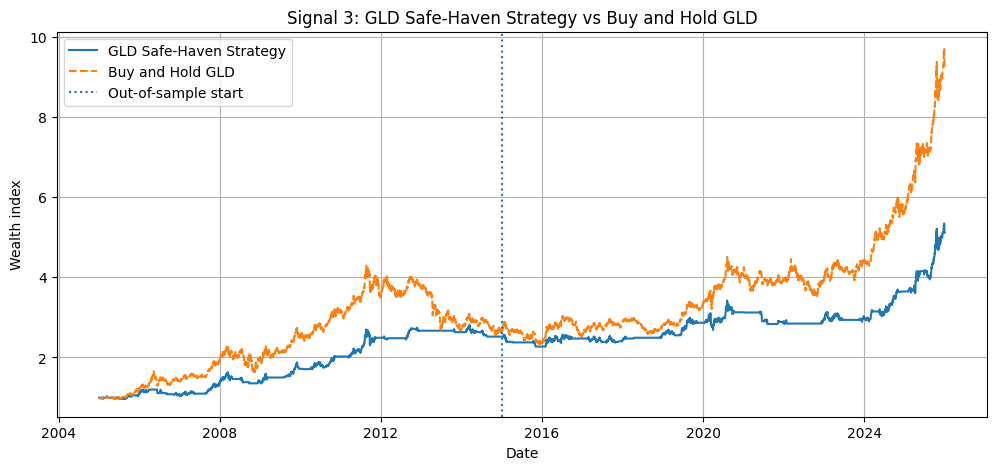

In [ ]:
# ============================================================
# Signal 3: Evaluate with selected parameters
# in-sample / out-of-sample / full sample
# ============================================================

def make_signal_3(price_series):
    """Build the gold safe-haven signal for any GLD price slice."""
    return module.gold_safe_haven_signal(
        gld_series              = price_series,
        tlt_series              = tlt_series,
        trend_window            = signal_3_trend_window,
        momentum_window         = signal_3_momentum_window,
        gld_momentum_threshold  = signal_3_gld_momentum_threshold,
        tlt_momentum_threshold  = signal_3_tlt_momentum_threshold
    )


# Build signals for each period
# NOTE: parameters were selected on in-sample only — no look-ahead
signal_3_in  = make_signal_3(gld_in_sample)
signal_3_out = make_signal_3(gld_out_sample)
signal_3_full = make_signal_3(gld_full)

# evaluate_signal_curve applies apply_execution_delay(shift=1) internally,
# so the signal at close t earns the return from t+1 to t+2 — no look-ahead
strategy_3_in,   bh_3_in,   stats_3_in,   bh_stats_3_in   = evaluate_signal_curve(gld_in_sample,  signal_3_in)
strategy_3_out,  bh_3_out,  stats_3_out,  bh_stats_3_out  = evaluate_signal_curve(gld_out_sample, signal_3_out)
strategy_3_full, bh_3_full, stats_3_full, bh_stats_3_full = evaluate_signal_curve(gld_full,       signal_3_full)

df_signal_3_statistics = build_statistics_table(
    strategy_name            = "GLD Safe-Haven Strategy",
    buy_hold_name            = "Buy and Hold GLD",
    in_sample_stats          = stats_3_in,
    buy_hold_in_sample_stats = bh_stats_3_in,
    out_sample_stats         = stats_3_out,
    buy_hold_out_sample_stats= bh_stats_3_out,
    full_sample_stats        = stats_3_full,
    buy_hold_full_sample_stats= bh_stats_3_full
)

print("Signal 3 — Performance Statistics")
display(df_signal_3_statistics)

plot_strategy_vs_buy_hold(
    strategy_curve     = strategy_3_full,
    buy_hold_curve     = bh_3_full,
    title              = "Signal 3: GLD Safe-Haven Strategy vs Buy and Hold GLD",
    strategy_label     = "GLD Safe-Haven Strategy",
    buy_hold_label     = "Buy and Hold GLD",
    out_of_sample_start= signal_3_out_sample_start
)

---
# Cross-Signal Comparison

Each of the four signals trades a **different underlying asset**, so we cannot put their wealth curves on a single chart and call it a fair comparison — a great year for gold has nothing to do with a great year for energy stocks.  

What we *can* compare fairly are **dimensionless, risk-adjusted metrics** that normalise for the differences between assets:

- **Sharpe ratio** — return per unit of volatility (dimensionless)
- **Max drawdown** — worst peak-to-trough loss (same scale for everyone)
- **Active share** — fraction of days the strategy is invested (same scale)

The key question we answer here is:
> *Does each signal add value compared to simply buying and holding its own asset?*

If our strategy Sharpe > buy-and-hold Sharpe for the same asset, the signal is doing something useful — it is timing the asset better than passive ownership.  

We show this for the **out-of-sample period only** (parameters were frozen before this period began).

In [ ]:
# ============================================================
# Cross-signal comparison — out-of-sample statistics table
# ============================================================

# Collect out-of-sample stats for all four strategies and their benchmarks
# Each row = one strategy or one buy-and-hold benchmark
comparison_rows = [
    ("S0 SPY VIX Strategy",   stats_0_out),
    ("S0 Buy & Hold SPY",     bh_0_out),
    ("S1 XLE Oil Strategy",   stats_1_out),
    ("S1 Buy & Hold XLE",     bh_1_out),
    ("S2 ITA Defensive",      stats_2_out),
    ("S2 Buy & Hold ITA",     bh_2_out),
    ("S3 GLD Safe-Haven",     stats_3_out),
    ("S3 Buy & Hold GLD",     bh_stats_3_out),
]

df_comparison = pd.DataFrame(
    {label: stats for label, stats in comparison_rows}
).T[["Annualized Return", "Annualized Volatility", "Sharpe Ratio", "Max Drawdown"]]

print("Out-of-Sample Comparison (parameters frozen; never used for calibration)")
display(df_comparison.round(4))

Out-of-Sample Comparison (parameters frozen; never used for calibration)


,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
S0 SPY VIX Strategy,0.0720,0.0818,0.8918,-0.1770
S0 Buy & Hold SPY,0.1354,0.1779,0.8033,-0.3372
S1 XLE Oil Strategy,0.0453,0.1356,0.3950,-0.4228
S1 Buy & Hold XLE,0.0523,0.2937,0.3216,-0.6681
S2 ITA Defensive,0.0333,0.0924,0.4011,-0.1752
S2 Buy & Hold ITA,0.1407,0.2225,0.7035,-0.5100
S3 GLD Safe-Haven,0.0724,0.1062,0.7111,-0.1714
S3 Buy & Hold GLD,0.1209,0.1475,0.8479,-0.2200


The strategy earnsly sloghzly less than just holding gold  (7.2% vs 12.1% annualised out-of-sample) but it does so with dramatically less volatility (10.6% vs 14.8%) and a shallower worst loss (-17.1% vs -22.0%). 
Better Max Drawdown but on the other hand when taking a look at the Sharpe ratio it performs worse.


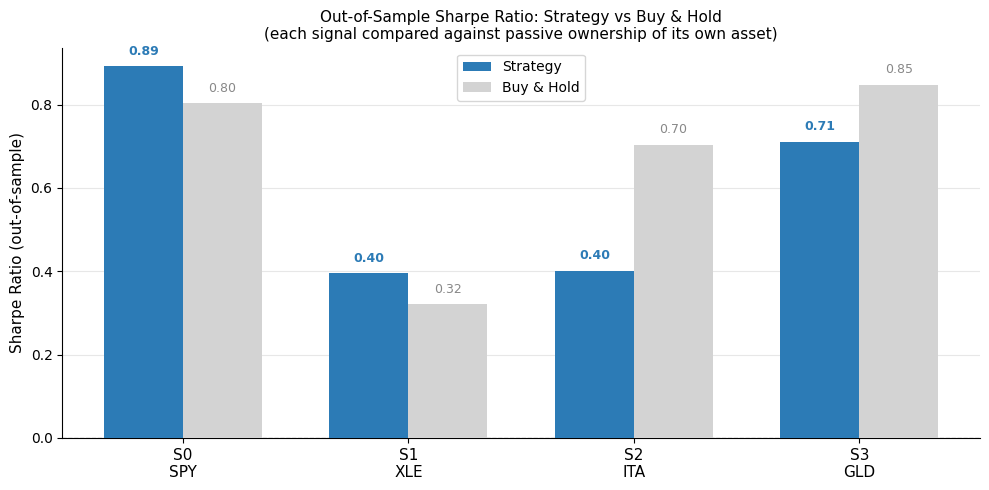

In [ ]:
# ============================================================
# Visualisation 1 — Sharpe ratio bar chart (strategy vs benchmark)
# The Sharpe ratio is dimensionless so it IS comparable across assets
# ============================================================

STRATEGY_COLOUR  = "#2c7bb6"
BENCHMARK_COLOUR = "#d3d3d3"

signal_labels = ["S0\nSPY", "S1\nXLE", "S2\nITA", "S3\nGLD"]

strategy_sharpes = [
    stats_0_out["Sharpe Ratio"],
    stats_1_out["Sharpe Ratio"],
    stats_2_out["Sharpe Ratio"],
    stats_3_out["Sharpe Ratio"],
]
benchmark_sharpes = [
    bh_0_out["Sharpe Ratio"],
    bh_1_out["Sharpe Ratio"],
    bh_2_out["Sharpe Ratio"],
    bh_stats_3_out["Sharpe Ratio"],
]

x      = np.arange(len(signal_labels))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_s = ax.bar(x - width / 2, strategy_sharpes,  width, color=STRATEGY_COLOUR,  label="Strategy",    zorder=3)
bars_b = ax.bar(x + width / 2, benchmark_sharpes, width, color=BENCHMARK_COLOUR, label="Buy & Hold",  zorder=3)

# Value labels on top of each bar
for bar in bars_s:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
            f"{h:.2f}", ha="center", va="bottom", fontsize=9, color=STRATEGY_COLOUR, fontweight="bold")

for bar in bars_b:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
            f"{h:.2f}", ha="center", va="bottom", fontsize=9, color="#888888")

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(signal_labels, fontsize=11)
ax.set_ylabel("Sharpe Ratio (out-of-sample)", fontsize=11)
ax.set_title(
    "Out-of-Sample Sharpe Ratio: Strategy vs Buy & Hold\n"
    "(each signal compared against passive ownership of its own asset)",
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

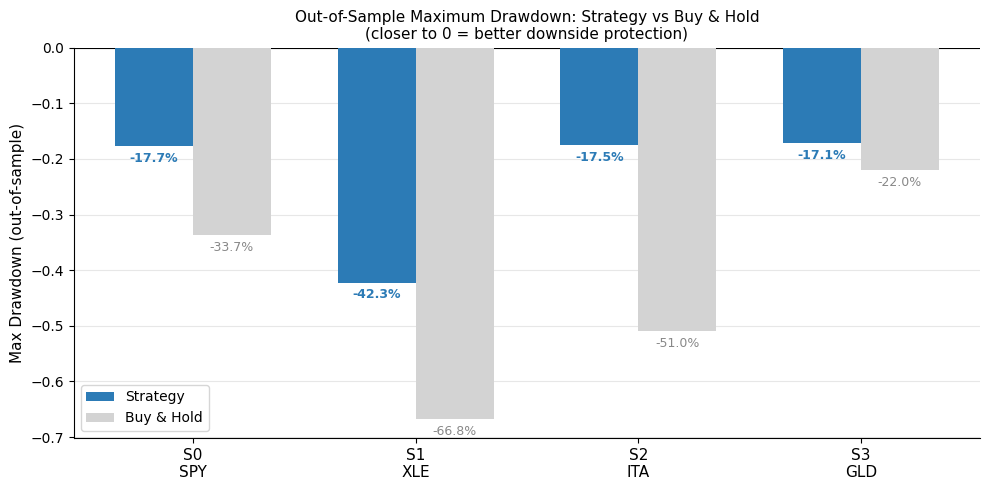

In [ ]:
# ============================================================
# Visualisation 2 — Max drawdown comparison
# Drawdown is always negative; closer to 0 = better protection
# ============================================================

strategy_dd = [
    stats_0_out["Max Drawdown"],
    stats_1_out["Max Drawdown"],
    stats_2_out["Max Drawdown"],
    stats_3_out["Max Drawdown"],
]
benchmark_dd = [
    bh_0_out["Max Drawdown"],
    bh_1_out["Max Drawdown"],
    bh_2_out["Max Drawdown"],
    bh_stats_3_out["Max Drawdown"],
]

fig, ax = plt.subplots(figsize=(10, 5))

bars_s = ax.bar(x - width / 2, strategy_dd,  width, color=STRATEGY_COLOUR,  label="Strategy",   zorder=3)
bars_b = ax.bar(x + width / 2, benchmark_dd, width, color=BENCHMARK_COLOUR, label="Buy & Hold", zorder=3)

for bar in bars_s:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h - 0.01,
            f"{h:.1%}", ha="center", va="top", fontsize=9, color=STRATEGY_COLOUR, fontweight="bold")

for bar in bars_b:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h - 0.01,
            f"{h:.1%}", ha="center", va="top", fontsize=9, color="#888888")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(signal_labels, fontsize=11)
ax.set_ylabel("Max Drawdown (out-of-sample)", fontsize=11)
ax.set_title(
    "Out-of-Sample Maximum Drawdown: Strategy vs Buy & Hold\n"
    "(closer to 0 = better downside protection)",
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

AttributeError: 'dict' object has no attribute 'to_numpy'

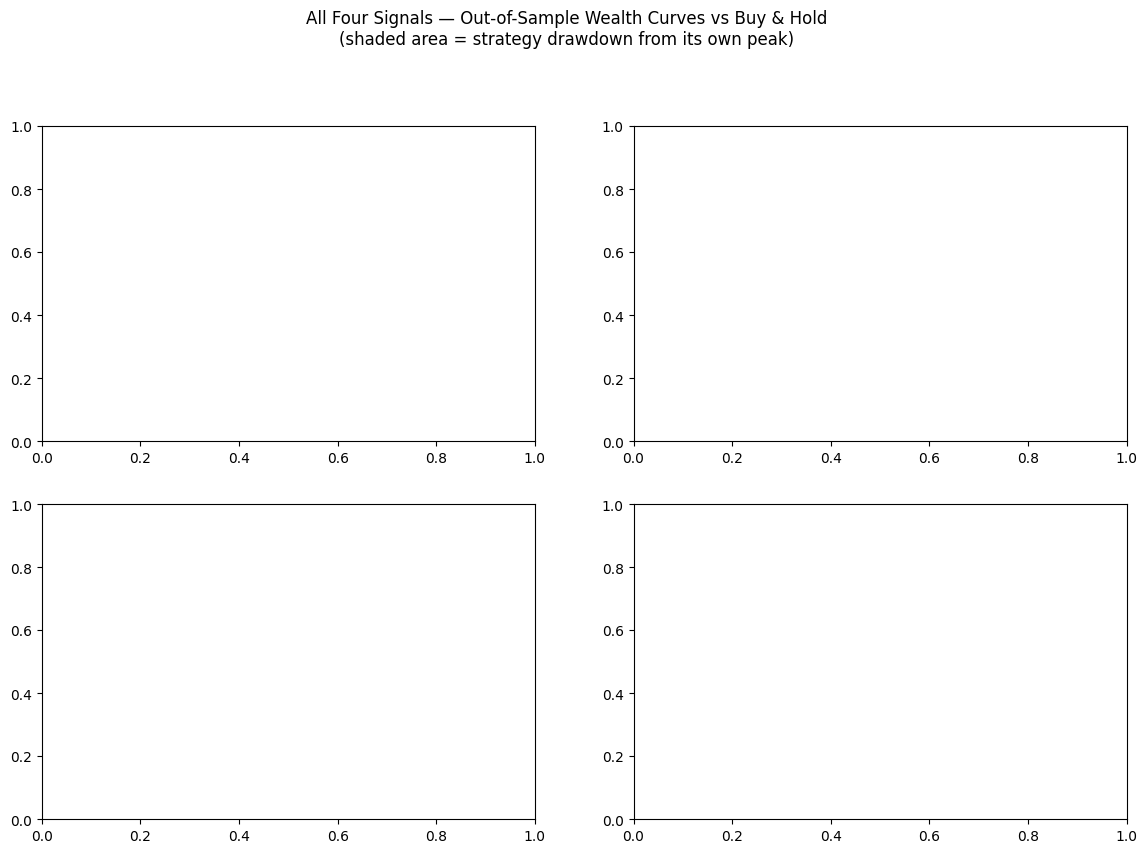

In [ ]:
# ============================================================
# Visualisation 3 — 2x2 wealth curve grid (out-of-sample)
# Each panel shows one signal's strategy vs its own buy-and-hold
# with a drawdown band shaded below the strategy curve
# ============================================================

def drawdown_series(portfolio_values):
    """Rolling drawdown from peak — values are <=0."""
    values = np.asarray(portfolio_values, dtype=float)
    running_max = np.maximum.accumulate(values)
    return values / running_max - 1.0


panels = [
    # (title, strategy_curve, bh_curve, strategy_label, bh_label, colour)
    ("S0 — SPY VIX Strategy (OOS)",
     strategy_0_out, bh_0_out, "SPY VIX Strategy", "Buy & Hold SPY", "#2c7bb6"),
    ("S1 — XLE Oil Strategy (OOS)",
     strategy_1_out, bh_1_out, "XLE Oil Strategy",  "Buy & Hold XLE", "#d7191c"),
    ("S2 — ITA Defensive Strategy (OOS)",
     strategy_2_out, bh_2_out, "ITA Defensive",      "Buy & Hold ITA", "#1a9641"),
    ("S3 — GLD Safe-Haven Strategy (OOS)",
     strategy_3_out, bh_3_out, "GLD Safe-Haven",     "Buy & Hold GLD", "#fdae61"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "All Four Signals — Out-of-Sample Wealth Curves vs Buy & Hold\n"
    "(shaded area = strategy drawdown from its own peak)",
    fontsize=12, y=1.01
)

for ax, (title, strat, bh, strat_label, bh_label, colour) in zip(axes.flat, panels):
    strat_arr = strat.to_numpy(dtype=float)
    bh_arr    = bh.to_numpy(dtype=float)
    dates     = strat.index
    dd        = drawdown_series(strat_arr)

    # Drawdown shading below the strategy curve
    strat_peak = np.maximum.accumulate(strat_arr)
    ax.fill_between(dates, strat_arr, strat_peak, alpha=0.15, color=colour, label="Drawdown")

    ax.plot(dates, strat_arr, color=colour,    lw=1.8, label=strat_label)
    ax.plot(dates, bh_arr,    color="#888888", lw=1.2, ls="--", label=bh_label)
    ax.axhline(1.0, color="black", lw=0.5, ls=":")

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Wealth index (start = 1.0)")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()